SKŁAD GRUP

Pearson: 11 grup, w tym 6 wieloelementowych
   F2, F3, F4, F8, F9, F14, F15, F20, F21, F26, F27
   F7, F11, F28
   F10, F13, F17
   F16, F19, F23
   F22, F25, F29
   F1, F5

Spearman: 11 grup, w tym 6 wieloelementowych
   F2, F3, F4, F8, F9, F14, F15, F20, F21, F26, F27
   F7, F11, F28
   F10, F13, F17
   F16, F19, F23
   F22, F25, F29
   F1, F5

Kendall: 12 grup, w tym 5 wieloelementowych
   F2, F3, F4, F8, F9, F14, F15, F20, F21, F26, F27
   F7, F11, F28
   F10, F13, F17
   F16, F19, F23
   F22, F25, F29

PARA F1--F5 (jedyna różnica między współczynnikami)
  Pearson   |r| = 0.9333   > 0.8
  Spearman  |r| = 0.9272   > 0.8
  Kendall   |r| = 0.7714   < 0.8

  Kendall przewidziany z Pearsona dla rozkładu normalnego:
    tau = (2/pi)*arcsin(0.9333) = 0.7662
  Zgodność z wartością zmierzoną potwierdza, że różnica
  12 vs 11 grup wynika ze skali współczynnika, nie z danych.

WRAŻLIWOŚĆ NA PRÓG
  prog |  Pearson | Spearman |  Kendall
  0.70 |       11 |       10 |       11
  0.75

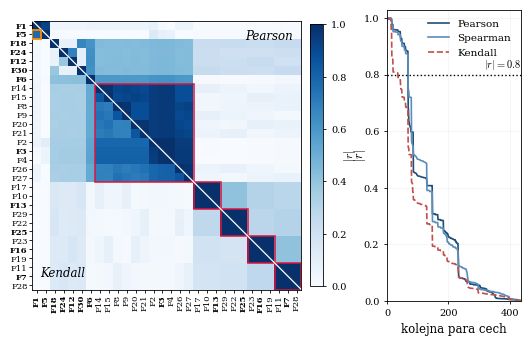

In [4]:
"""
Rysunek 4.1 -- macierz korelacji cech z podziałem na grupy.

Jeden rysunek, dwa panele:
  * lewy  -- macierz |r|; dolny trójkąt Kendall, górny Pearson,
             cechy uporządkowane tak, aby grupy leżały obok siebie,
             czerwone ramki = spójne składowe grafu |r| > 0.8 (Kendall),
             pogrubione etykiety = reprezentanci (końcowy zestaw 12 cech);
  * prawy -- uporządkowane malejąco |r| dla wszystkich 435 par, osobno
             dla trzech współczynników, z zaznaczonym progiem.

Prawy panel pokazuje, że krzywa Kendalla leży systematycznie niżej niż
pozostałe -- to wyjaśnia, dlaczego ten sam próg 0.8 daje dla Kendalla
12 grup, a dla Pearsona i Spearmana 11.

PDF zapisywany jest w rozmiarze docelowym -> wstawiać BEZ skalowania.
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import networkx as nx
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# ============================================================
# KONFIGURACJA
# ============================================================

SCIEZKA_DANYCH = "../data/processed/FULL_30.npz"
KLUCZ_X = "X"

PROG = 0.8
TEXT_WIDTH_IN = 6.3          # szerokość szpalty w calach (~16 cm)
PLIK_WY = "rysunek_4_1_korelacje.pdf"

# Reprezentanci grup -- zweryfikowane wobec sekcji 4.2.3:
#   grupa {F2,F3,F4,F8,F9,F14,F15,F20,F21,F26,F27} -> F3
#   grupa {F10,F13,F17}                            -> F13
#   grupa {F7,F11,F28}                             -> F7
#   grupa {F16,F19,F23}                            -> F16
#   grupa {F22,F25,F29}                            -> F25
#   singletony: F1, F5, F6, F12, F18, F24, F30
REPREZENTANCI = {
    "F1", "F3", "F5", "F6", "F7", "F12",
    "F13", "F16", "F18", "F24", "F25", "F30",
}

mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})


# ============================================================
# DANE
# ============================================================

def wczytaj_dane(sciezka=SCIEZKA_DANYCH, klucz=KLUCZ_X):
    dane = np.load(sciezka, allow_pickle=True)
    X = dane[klucz]
    cechy = [f"F{i}" for i in range(1, X.shape[1] + 1)]
    return pd.DataFrame(X, columns=cechy)


def macierze_korelacji(df):
    return {
        "Pearson": df.corr(method="pearson"),
        "Spearman": df.corr(method="spearman"),
        "Kendall": df.corr(method="kendall"),
    }


# ============================================================
# GRUPOWANIE
# ============================================================

def grupy(C, prog=PROG):
    """Spójne składowe grafu, w którym krawędź istnieje dla |r| > prog."""
    G = nx.Graph()
    G.add_nodes_from(C.columns)
    A = np.abs(C.values)
    n = len(C.columns)
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] > prog:
                G.add_edge(C.columns[i], C.columns[j])
    return sorted(
        (sorted(k, key=lambda s: int(s[1:])) for k in nx.connected_components(G)),
        key=lambda g: (-len(g), int(g[0][1:])),
    )


def kolejnosc_cech(C):
    """Porządek liści grupowania hierarchicznego -- grupy leżą obok siebie."""
    D = 1.0 - np.abs(C.values)
    D = (D + D.T) / 2.0
    np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method="single")
    return [C.columns[i] for i in leaves_list(Z)]


# ============================================================
# DIAGNOSTYKA -- uruchom PRZED wstawieniem rysunku do pracy
# ============================================================

def raport(df):
    M = macierze_korelacji(df)

    print("=" * 66)
    print("SKŁAD GRUP")
    print("=" * 66)
    for nazwa, C in M.items():
        g = grupy(C)
        wielo = [x for x in g if len(x) > 1]
        print(f"\n{nazwa}: {len(g)} grup, w tym {len(wielo)} wieloelementowych")
        for x in wielo:
            print("   " + ", ".join(x))

    print("\n" + "=" * 66)
    print("PARA F1--F5 (jedyna różnica między współczynnikami)")
    print("=" * 66)
    r_p = abs(M["Pearson"].loc["F1", "F5"])
    for nazwa, C in M.items():
        v = abs(C.loc["F1", "F5"])
        print(f"  {nazwa:9s} |r| = {v:.4f}   {'>' if v > PROG else '<'} {PROG}")
    tau_teor = (2 / np.pi) * np.arcsin(r_p)
    print(f"\n  Kendall przewidziany z Pearsona dla rozkładu normalnego:")
    print(f"    tau = (2/pi)*arcsin({r_p:.4f}) = {tau_teor:.4f}")
    print("  Zgodność z wartością zmierzoną potwierdza, że różnica")
    print("  12 vs 11 grup wynika ze skali współczynnika, nie z danych.")

    print("\n" + "=" * 66)
    print("WRAŻLIWOŚĆ NA PRÓG")
    print("=" * 66)
    print(f"{'prog':>6} | " + " | ".join(f"{n:>8}" for n in M))
    for p in (0.70, 0.75, 0.80, 0.85, 0.90, 0.95):
        wiersz = " | ".join(f"{len(grupy(C, p)):>8d}" for C in M.values())
        print(f"{p:>6.2f} | {wiersz}")

    return M


# ============================================================
# RYSUNEK
# ============================================================

def rysuj(df, plik=PLIK_WY):
    M = macierze_korelacji(df)
    C_dol, C_gora = M["Kendall"], M["Pearson"]

    kolejnosc = kolejnosc_cech(C_dol)
    n = len(kolejnosc)
    idx = {c: i for i, c in enumerate(kolejnosc)}

    A_dol = np.abs(C_dol.loc[kolejnosc, kolejnosc].values)
    A_gora = np.abs(C_gora.loc[kolejnosc, kolejnosc].values)
    maska_dol = np.tril(np.ones((n, n), dtype=bool))
    M_lacz = np.where(maska_dol, A_dol, A_gora)

    fig = plt.figure(figsize=(TEXT_WIDTH_IN, TEXT_WIDTH_IN * 0.60))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 0.46], wspace=0.30)
    ax = fig.add_subplot(gs[0])
    ax_r = fig.add_subplot(gs[1])

    im = ax.imshow(M_lacz, vmin=0, vmax=1, cmap="Blues", aspect="equal")

    # --- obrysy grup --------------------------------------------------
    for g in grupy(C_dol):
        if len(g) < 2:
            continue
        poz = sorted(idx[c] for c in g)
        if poz[-1] - poz[0] != len(poz) - 1:
            print(f"UWAGA: grupa {g} nie jest ciągła w przyjętej kolejności.")
        a, b = poz[0], poz[-1]
        ax.add_patch(Rectangle(
            (a - 0.5, a - 0.5), b - a + 1, b - a + 1,
            fill=False, edgecolor="crimson", linewidth=1.1, zorder=3,
        ))

    # --- przekątna rozdzielająca trójkąty -----------------------------
    ax.plot([-0.5, n - 0.5], [-0.5, n - 0.5],
            color="white", linewidth=0.9, zorder=4)
    ax.text(0.03, 0.05, "Kendall", transform=ax.transAxes,
            fontsize=8.5, style="italic", zorder=5)
    ax.text(0.97, 0.93, "Pearson", transform=ax.transAxes,
            fontsize=8.5, style="italic", ha="right", zorder=5)

    # --- wskazanie pary F1--F5 ----------------------------------------
    if "F1" in idx and "F5" in idx:
        i1, i5 = idx["F1"], idx["F5"]
        ax.add_patch(Rectangle(
            (min(i1, i5) - 0.5, max(i1, i5) - 0.5), 1, 1,
            fill=False, edgecolor="darkorange", linewidth=1.3, zorder=5,
        ))

    # --- etykiety ------------------------------------------------------
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(kolejnosc, rotation=90, fontsize=6)
    ax.set_yticklabels(kolejnosc, fontsize=6)
    for grupa_etykiet in (ax.get_xticklabels(), ax.get_yticklabels()):
        for t in grupa_etykiet:
            if t.get_text() in REPREZENTANCI:
                t.set_fontweight("bold")
    ax.tick_params(length=2, pad=1.5)

    cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    cb.set_label(r"$|r|$", fontsize=9)
    cb.ax.tick_params(labelsize=7, length=2)
    cb.outline.set_linewidth(0.6)

    # --- prawy panel: uporządkowane |r| --------------------------------
    style = {
        "Pearson":  ("#1f4e79", "-"),
        "Spearman": ("#5b8db8", "-"),
        "Kendall":  ("#c0504d", "--"),
    }
    for nazwa, (kolor, ls) in style.items():
        A = np.abs(M[nazwa].values)
        war = np.sort(A[np.triu_indices(n, k=1)])[::-1]
        ax_r.plot(np.arange(1, war.size + 1), war,
                  lw=1.2, ls=ls, color=kolor, label=nazwa)

    ax_r.axhline(PROG, ls=":", lw=1.0, color="black")
    ax_r.text(war.size, PROG + 0.025, f"$|r| = {PROG}$",
              fontsize=7.5, ha="right")
    ax_r.set_xlabel("kolejna para cech", fontsize=8.5)
    ax_r.set_ylabel(r"$|r|$", fontsize=8.5)
    ax_r.set_ylim(0, 1.03)
    ax_r.set_xlim(0, war.size)
    ax_r.tick_params(labelsize=7, length=2)
    ax_r.legend(fontsize=7.5, frameon=False, loc="upper right")
    ax_r.grid(alpha=0.18, lw=0.5)

    fig.savefig(plik, bbox_inches="tight", pad_inches=0.02)
    print(f"\nZapisano: {Path(plik).resolve()}")
    return fig



dane = wczytaj_dane()
raport(dane)
rysuj(dane)
plt.show()